**Lamda Functions**

In [48]:
# Example 1
square = lambda x: x*x
square(10)

100

In [49]:
# Example 2
add = lambda x, y: x + y
add(5, 3)

8

In [50]:
nums = [1, 2, 3, 4, 5]
square = list(map(lambda x: x*x, nums))
print(square)

[1, 4, 9, 16, 25]


**Agent 1**

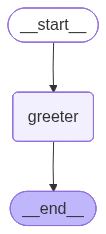

'Bob, you are doing an amazing job learning LangGraph!'

In [51]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict): # state schema
    message: str

def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state."""

    state['message'] = state['message'] + ", you are doing an amazing job learning LangGraph!"

    return state

graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

result = app.invoke({"message": "Bob"})

result["message"]

**Agent II**

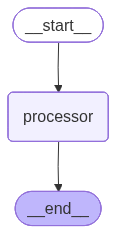

old state: {'values': [1, 2, 3, 4], 'name': 'Alice'}
new state: {'values': [1, 2, 3, 4], 'name': 'Alice', 'result': 'Hi there Alice! The sum = 10.'}
output: {'values': [1, 2, 3, 4], 'name': 'Alice', 'result': 'Hi there Alice! The sum = 10.'}
output['result']: Hi there Alice! The sum = 10.


In [52]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""

    print(f"old state: {state}")
    state['result'] = f"Hi there {state['name']}! The sum = {sum(state['values'])}."
    print(f"new state: {state}")

    return state

graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

output = app.invoke({"name": "Alice", "values": [1, 2, 3, 4]})

print(f"output: {output}")
print(f"output['result']: {output['result']}")

**Exercise II**

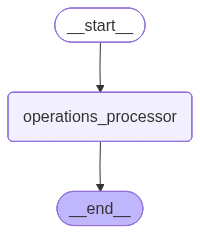

old state: {'name': 'John', 'values': [1, 2, 3, 4, 5], 'operation': '+'}
new state: {'name': 'John', 'values': [1, 2, 3, 4, 5], 'operation': '+', 'result': 'Hi John, your sum is: 15'}
output: {'name': 'John', 'values': [1, 2, 3, 4, 5], 'operation': '+', 'result': 'Hi John, your sum is: 15'}
output['result']: Hi John, your sum is: 15


In [53]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
from functools import reduce

class AgentState(TypedDict):
    name: str
    values: List[int]
    operation: str
    result: str

def process_values_with_operations(state: AgentState) -> AgentState:
    """This function handles multiple different operations"""

    print(f"old state: {state}")

    if state['operation'] == "+":
        state['result'] = f"Hi {state['name']}, your sum is: {sum(state['values'])}"
    elif state['operation'] == '*':
        state['result'] = f"Hi {state['name']}, your product is: {reduce(lambda x, y: x*y, state['values'])}"
    else:
        print("Invalid operation")
    
    print(f"new state: {state}")

    return state

graph = StateGraph(AgentState)
graph.add_node("operations_processor", process_values_with_operations)
graph.set_entry_point("operations_processor")
graph.set_finish_point("operations_processor")

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

output = app.invoke({"name": "John", "values": [1,2,3,4,5], "operation": "+"})

print(f"output: {output}")
print(f"output['result']: {output['result']}")


**Graph III**

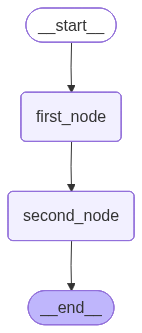

Output: {'name': 'Yoman', 'age': '25', 'final': 'Hi Yoman! You are 25 years old!'}
Output['final']: Hi Yoman! You are 25 years old!
Output['final']: Hi Yoman! You are 25 years old!


In [54]:
from typing import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    name: str
    age: str
    final: str

def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""

    state["final"] = f"Hi {state['name']}!"

    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence"""

    # state["final"] = state["final"] + f"You are {state["age"]} years old!"
    state["final"] = state["final"] + f" You are {state['age']} years old!"

    return state

graph = StateGraph(AgentState)
graph.add_node("first_node", first_node)
graph.add_edge("first_node", "second_node")
graph.add_node("second_node", second_node)
graph.set_entry_point("first_node")
graph.set_finish_point("second_node")

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

output = app.invoke({"name": "Yoman", "age": "25"})
print("Output:", output)
print("Output['final']:", output["final"])
print(f"Output['final']: {output['final']}")

**Exercise III**

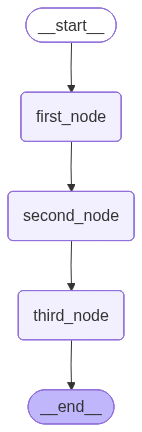

Output: {'name': 'Yoman', 'age': '25', 'skills': ['Python', 'Machine Learning', 'LangGraph'], 'final': 'Hi Yoman! You are 25 years old! You have skills in: Python, Machine Learning, and LangGraph.'}
Output['final']: Hi Yoman! You are 25 years old! You have skills in: Python, Machine Learning, and LangGraph.
Output['final']: Hi Yoman! You are 25 years old! You have skills in: Python, Machine Learning, and LangGraph.


In [55]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]
    final: str

def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence that personalizes the greeting using name field"""

    state["final"] = f"Hi {state['name']}!"

    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence that describes the user's age"""

    # state["final"] = state["final"] + f"You are {state["age"]} years old!"
    state["final"] = state["final"] + f" You are {state['age']} years old!"

    return state

def third_node(state: AgentState) -> AgentState:
    """This is the third node of our sequence that lists the user's skills in a formatted string"""

    if len(state['skills']) == 1:
        state["final"] = state["final"] + f" You have skills in: {state['skills'][0]}."
    elif len(state['skills']) == 2:
        state["final"] = state["final"] + f" You have skills in: {' and '.join(state['skills'])}."
    else:
        state["final"] = state["final"] + f" You have skills in: {', '.join(state['skills'][:-1])}, and {state['skills'][-1]}."

    return state

graph = StateGraph(AgentState)
graph.add_node("first_node", first_node)
graph.add_edge("first_node", "second_node")
graph.add_node("second_node", second_node)
graph.add_edge("second_node", "third_node")
graph.add_node("third_node", third_node)

graph.set_entry_point("first_node")
graph.set_finish_point("third_node")

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

output = app.invoke({"name": "Yoman", "age": "25", "skills": ["Python", "Machine Learning", "LangGraph"]})
print("Output:", output)
print("Output['final']:", output["final"])
print(f"Output['final']: {output['final']}")

**Graph IV**

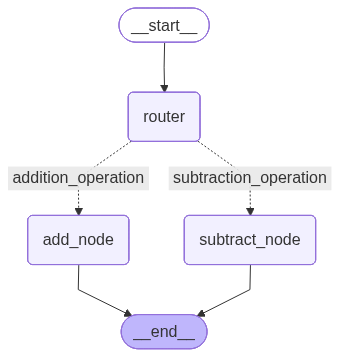

{'num1': 10, 'operation': '+', 'num2': 5, 'result': 15}


In [56]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
    num1: int
    operation: str
    num2: int
    result: int

def adder(state: AgentState) -> AgentState:
    """This node adds two integers"""
    state["result"] = state["num1"] + state["num2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts two integers"""
    state["result"] = state["num1"] - state["num2"]
    return state

def decide_next_node(state: AgentState) -> str:
    """This node will select the next node of the graph"""
    
    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"
    else:
        return "invalid_operation"

graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state) # passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge name: node name
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

initial_state = AgentState(num1=10, operation="+", num2=5)
result = app.invoke(initial_state)
print(result)

**Exercise IV**

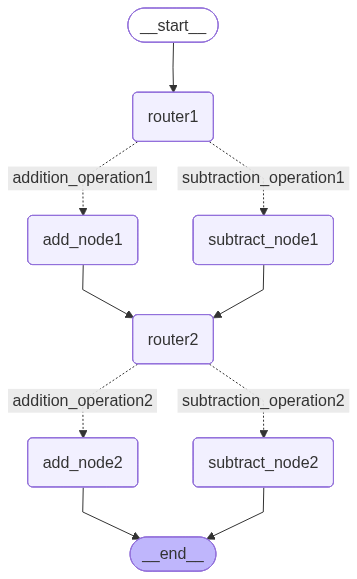

{'num1': 10, 'operation1': '+', 'num2': 5, 'result1': 15, 'num3': 5, 'operation2': '-', 'num4': 2, 'result2': 3}


In [57]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
    num1: int
    operation1: str
    num2: int
    result1: int
    num3: int
    operation2: str
    num4: int
    result2: int

def adder1(state: AgentState) -> AgentState:
    """This node adds the first two integers"""
    state["result1"] = state["num1"] + state["num2"]
    return state

def subtractor1(state: AgentState) -> AgentState:
    """This node subtracts the first two integers"""
    state["result1"] = state["num1"] - state["num2"]
    return state

def adder2(state: AgentState) -> AgentState:
    """This node adds the second two integers"""
    state["result2"] = state["num3"] + state["num4"]
    return state

def subtractor2(state: AgentState) -> AgentState:
    """This node subtracts the second two integers"""
    state["result2"] = state["num3"] - state["num4"]
    return state

def decide_next_node1(state: AgentState) -> str:
    """This node will select the next node of the graph"""
    
    if state["operation1"] == "+":
        return "addition_operation1"
    elif state["operation1"] == "-":
        return "subtraction_operation1"
    else:
        return "invalid_operation"
    
def decide_next_node2(state: AgentState) -> str:
    """This node will select the next node of the graph"""
    
    if state["operation2"] == "+":
        return "addition_operation2"
    elif state["operation2"] == "-":
        return "subtraction_operation2"
    else:
        return "invalid_operation"

graph = StateGraph(AgentState)

graph.add_node("add_node1", adder1)
graph.add_node("subtract_node1", subtractor1)
graph.add_node("router1", lambda state:state) # passthrough function
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router2", lambda state:state) # passthrough function

graph.add_edge(START, "router1")

graph.add_conditional_edges(
    "router1",
    decide_next_node1,
    {
        # Edge name: node name
        "addition_operation1": "add_node1",
        "subtraction_operation1": "subtract_node1"
    }
)

graph.add_edge("add_node1", "router2")
graph.add_edge("subtract_node1", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        # Edge name: node name
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

initial_state = AgentState(num1=10, operation1="+", num2=5, num3=5, operation2="-", num4=2)
result = app.invoke(initial_state)
print(result)

**Graph V**

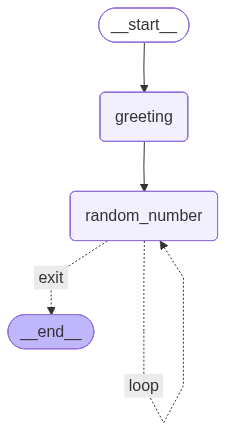

Hi Ali!
Running random_number_generator for the time: 0
Running random_number_generator for the time: 1
Running random_number_generator for the time: 2
Running random_number_generator for the time: 3
Running random_number_generator for the time: 4
{'name': 'Ali', 'numbers': [4, 4, 7, 5, 8], 'counter': 5}


In [58]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from random import randint

class AgentState(TypedDict):
    name: str
    numbers: List[int]
    counter: int

def greeting_node(state: AgentState) -> AgentState:
    """Function that greets the user"""
    print(f"Hi {state['name']}!")
    state["counter"] = 0 # Added hard condition to set counter to zero, ignoring the user-provided initial counter value
    return state

def random_number_generator(state: AgentState) -> AgentState:
    """Function that generates a random number"""
    print(f"Running random_number_generator for the time: {state['counter']}")
    state["numbers"].append(randint(0,10))
    state["counter"] += 1
    return state

def should_continue(state: AgentState) -> str:
    if state["counter"] < 5:
        return "loop"
    else:
        return "exit"

graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random_number", random_number_generator)

graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random_number")

graph.add_conditional_edges(
    "random_number", # source node
    should_continue, # action / 
    {
        "loop": "random_number", # loop back to the source node
        "exit": END # exit the loop and end the graph
    }

)

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

initial_state = AgentState(name="Ali", numbers=[], counter=0) # the counter initial condition is ignored due to the hard reset in the greeting node
result = app.invoke(initial_state)
print(result)

**Exercise V**

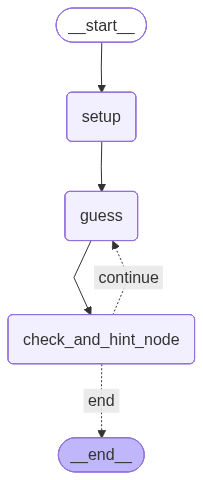

The target number is: 3
Hello Student!
Attempt 1: Guessing 9
The guess was too high. Adjusting upper bound...
Attempt 2: Guessing 8
The guess was too high. Adjusting upper bound...
Attempt 3: Guessing 5
The guess was too high. Adjusting upper bound...
Attempt 4: Guessing 4
The guess was too high. Adjusting upper bound...
Attempt 5: Guessing 3
The guess is correct! Game over :)
Final state: {'player_name': 'Student', 'lower_bound': 1, 'upper_bound': 4, 'guesses': [9, 8, 5, 4, 3], 'current_guess': 3, 'attempts_made': 5, 'max_attempts': 7, 'target_number': 3, 'game_over': True}


In [15]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from random import randint

class AgentState(TypedDict):
    player_name: str
    lower_bound: int
    upper_bound: int
    guesses: List[int]
    current_guess: int
    attempts_made: int
    max_attempts: int
    target_number: int
    game_over: bool


def setup(state: AgentState) -> AgentState:
    """This function sets up the game"""

    state['target_number'] = randint(state['lower_bound'], state['upper_bound'])
    print(f"The target number is: {state['target_number']}")
    state["game_over"] = False
    state['attempts_made'] = 1
    print(f"Hello {state['player_name']}!")

    return state


def guess(state: AgentState) -> AgentState:
    """This function tries to randomly guess a number between lower and upper bounds"""

    state['current_guess'] = randint(state['lower_bound'], state['upper_bound'])
    state["guesses"].append(state["current_guess"])
    print(f"Attempt {state['attempts_made']}: Guessing {state['current_guess']}")

    return state


def check_and_hint_node(state: AgentState) -> AgentState:
    """This function checks if the guess is correct. If incorrect, it gives a hint and loops back to guess node."""
    if state["attempts_made"] >= state["max_attempts"]:
        print("Reached maxed attempts allowed. Game over :(")
        state["game_over"] = True
        return state
    else:
        if state['current_guess'] == state['target_number']:
            print("The guess is correct! Game over :)")
            state["game_over"] = True
            return state
        else:
            state['attempts_made'] += 1
            if state["current_guess"] < state["target_number"]:
                print("The guess was too low. Adjusting lower bound...")
                state["lower_bound"] = state["current_guess"]
            elif state["current_guess"] > state["target_number"]:
                print("The guess was too high. Adjusting upper bound...")
                state["upper_bound"] = state["current_guess"]
            return state


def router(state: AgentState) -> str:
    "This function routes the game to end if the game_over state is True"
    if state.get("game_over"):
        return "end"
    return "continue"


graph = StateGraph(AgentState)

graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("check_and_hint_node", check_and_hint_node)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "check_and_hint_node")

graph.add_conditional_edges(
    "check_and_hint_node", # source node
    router,                # router function
    {                      # mapping (to sink node based on condition)
        "continue": "guess",
        "end": END
    }
)

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

initial_conditions = AgentState(player_name="Student", guesses=[], lower_bound=1, upper_bound=20, max_attempts=7)
final_state = app.invoke(initial_conditions)
print(f"Final state: {final_state}")


---
**Agent I - Basic LLM caller (no memory)**

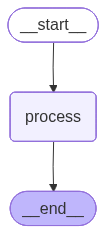


AI: How can I assist you today?

AI: I’m a large language model. I don’t have personal experiences, but I can provide information and answer questions on a wide range of topics. I’m constantly learning and improving, so my knowledge and abilities are constantly expanding. I can assist with tasks such as generating text, answering questions, and even creating content like stories or dialogues. I’m here to provide information and help with any questions you may have.


In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

class AgentState(TypedDict):
    messages: List[HumanMessage]

# to use ChatGPT from OpenAI servers
#llm = ChatOpenAI(model="gpt-5-nano")

# to use local LLMs from OpenAI API-compatible local servers (like llama.cpp (llama-server) and others)
llm = ChatOpenAI(
    model="local-model",
    base_url="http://localhost:8080/v1",
    api_key="none"
)

def process(state: AgentState) -> AgentState:
    """This node sends a human message to LLM"""
    response = llm.invoke(state["messages"])
    print(f"\nAI: {response.content}")
    return state


graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)

agent = graph.compile()

from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

user_input = input("Enter user input: ")
while user_input != "exit":
    agent.invoke({"messages": [HumanMessage(content=user_input)]})
    user_input = input("Enter user input: ")


**Agent II - Basic chatbot with memory and file-based persistence as end-of-conversation text dump**

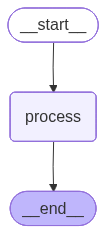


Conversation history before messages: [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={})]

AI: How can I assist you today?

Messages state in process node: [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}), AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

Conversation history after messages: [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}), AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

Conversation history before messages: [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}), AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='My name is John', additional_kwargs={}, response_metadata={})]

AI: Nice to meet you, John! Is there somethi

In [5]:
from typing import TypedDict, List, Union
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]

# OpenAI LLMs
# llm = ChatOpenAI(model="gpt-5-nano")

# Local LLMs using OpenAI-compatible API
llm = ChatOpenAI(
    model="local-model",
    base_url="http://localhost:8080/v1",
    api_key="none"
)

def process(state: AgentState) -> AgentState:
    """This node sends """
    response = llm.invoke(state["messages"])

    state["messages"].append(AIMessage(content=response.content))
    print(f"\nAI: {response.content}")

    print(f"\nMessages state in process node: {state['messages']}")

    return state

graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)

agent = graph.compile()

from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

conversation_history = []

user_input = input("Enter user input: ")
while user_input != "exit":
    conversation_history.append(HumanMessage(content=user_input))

    print(f"\nConversation history before messages: {conversation_history}")

    result = agent.invoke({"messages": conversation_history})
    
    conversation_history = result["messages"]

    print(f"\nConversation history after messages: {conversation_history}")

    user_input = input("Enter user input: ")

# Save conversation to file
with open("logging.txt", "w") as file:
    file.write("Conversation Log:\n")
    for message in conversation_history:
        if isinstance(message, HumanMessage):
            file.write(f"You: {message.content}\n")
        elif isinstance(message, AIMessage):
            file.write(f"AI: {message.content}\n\n")
    file.write("End of Conversation")
print("Conversation saved to file logging.txt")

**Agent III - ReAct (Reasoning and Acting) Agent**

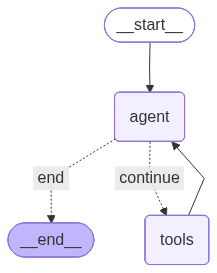

================================ Human Message =================================

Add 3 + 4. Subtract 10 from 12. Multiply the results together. Finally, if the result of multiplication is even, divide by 2, else return the multiplication result as final.
================================== Ai Message ==================================
Tool Calls:
  add (vT8vwdu1plIq8xqsz3VdZn6LnbclGRNC)
 Call ID: vT8vwdu1plIq8xqsz3VdZn6LnbclGRNC
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (hBJjFt6RTaWPU6hcXstNvKJuraiS1kNa)
 Call ID: hBJjFt6RTaWPU6hcXstNvKJuraiS1kNa
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================

7


In [ ]:
from typing import TypedDict, Annotated, Sequence
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

load_dotenv()

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def add(a:int, b:int):
    """This is an addition function to add two numbers."""
    return a + b

@tool
def subtract(a:int, b:int):
    """This is a subtraction function to subtract second number from the first."""
    return a - b

@tool
def multiply(a:int, b:int):
    """This is a multiplication function to multiply two numbers."""
    return a * b

@tool
def divide(a:int, b:int):
    """This is a division function to divide first number by second number."""
    return a / b

tools = [add, subtract, multiply, divide]

# OpenAI LLMs
#llm = ChatOpenAI(model="gpt-5-nano").bind_tools(tools)

# Local LLMs using OpenAI-compatible API
# Note: Local LLMs like gpt-oss-20b and llama-3.1-8b don't seem to perform well on 4-bit (Q4_K_M) quantization. Need to look into this further.
llm = ChatOpenAI(
    model="local-model",
    base_url="http://localhost:8080/v1",
    api_key="none"
).bind_tools(tools)


def llm_call(state:AgentState) -> AgentState:
    system_prompt = SystemMessage(content=
        "You are my AI assistant, please answer my query to the best of your ability."
    )
    response = llm.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}

def should_continue(state:AgentState) -> str:
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"
    
graph = StateGraph(AgentState)
graph.add_node("agent", llm_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.add_edge(START, "agent")
graph.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",
        "end": END
    }
)
graph.add_edge("tools", "agent")

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": ["user", "Add 3 + 4. Subtract 10 from 12. Multiply the results together. Finally, if the result of multiplication is even, divide by 2, else return the multiplication result as final."]}
print_stream(app.stream(inputs, stream_mode="values"))


**Agent IV - Human-in-the-Loop Document Drafter Agent**

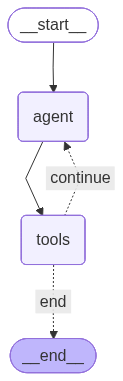


 ===== DRAFTER =====

AI: Sure! To get started, could you share a bit more detail about the email you’d like to send? For example:

1. **Recipient** – who’s it to (name, position, company)?
2. **Subject line** – what’s the main topic or purpose?
3. **Tone** – formal, friendly, persuasive, etc.?
4. **Key points** – any specific details or requests you want included?
5. **Any attachments** or additional info that should be mentioned?

Once I have those details, I can draft a polished email for you.

USER: Write me an email for John, my colleague, telling him that I won't be able to make it to the meeting by 3 PM today but I'll reconnect with the project manager at 4PM to get details on the project so we can start on it tomorrow.

AI: 
USING TOOLS: ['update']

TOOL RESULT: Document has been updated successfully! The current content is:
Subject: Quick Update on Today’s Meeting

Hi John,

I wanted to let you know I won’t be able to make it to the 3 PM meeting today. I’ll be meeting with th

In [1]:
from typing import TypedDict, Annotated, Sequence
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

load_dotenv()

# Global variable to temporarily hold document content for tool calls before saving to file
# A better way to do this is by InjectedState (look into this later) 
document_content = ""

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def update(content: str) -> str:
    """Updates the document with the provided content."""
    global document_content
    document_content = content
    return f"Document has been updated successfully! The current content is:\n{document_content}"


@tool
def save(filename: str) -> str:
    """Saves the current document to a text file and finish the process.
    
    Args:
        filename: Name for the text file.
    """

    global document_content

    if not filename.endswith(".txt"):
        filename = f"{filename}.txt"
    
    try:
        with open(filename, "w") as file:
            file.write(document_content)
        print(f"\nDocument has been saved to: {filename}")
        return f"Document has been saved successfully to: '{filename}'."

    except Exception as e:
        return f"Error saving document: {str(e)}"


tools = [update, save]

# OpenAI LLMs
# llm = ChatOpenAI(model="gpt-5-nano").bind_tools(tools)

# Local LLMs using OpenAI-compatible API
# Note: Local LLMs like gpt-oss-20b and llama-3.1-8b don't seem to perform well on 4-bit (Q4_K_M) quantization. Need to look into this further.
llm = ChatOpenAI(
    model="local-model",
    base_url="http://localhost:8080/v1",
    api_key="none"
).bind_tools(tools)


def agent(state:AgentState) -> AgentState:
    system_prompt = SystemMessage(content=f"""
    You are Drafter, a helpful writing assistant. You are going to help the user update and modify documents.

    - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
    - If the user wants to save and finish, you need to use the 'save' tool.
    - Make sure to always show the current document state after modifications.
    
    The current document content is: {document_content}                              
    """)

    if not state["messages"]:
        user_input = input("I'm ready to help you update a document. What would you like to create?")
        user_message = HumanMessage(content=user_input)
    else:
        user_input = input("\nWhat would you like to do with the document?")
        print(f"\nUSER: {user_input}")
        user_message = HumanMessage(content=user_input)

    all_messages = [system_prompt] + list(state["messages"]) + [user_message]

    response = llm.invoke(all_messages)

    print(f"\nAI: {response.content}")
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")

    return {"messages": list(state["messages"]) + [user_message, response]}


def should_continue(state: AgentState) -> str:
    """Determine if we should continue or end the conversation."""

    messages = state["messages"]

    if not messages:
        return "continue"
    
    # looks for the most recent tool message
    for message in reversed(messages):
        if (isinstance(message, ToolMessage) and "saved" in message.content.lower() and "document" in message.content.lower()):
            return "end"
    return "continue"


def print_messages(messages):
    """Function to print messages in a more readable format."""
    if not messages:
        return
    
    for message in messages[-3:]:
        if isinstance(message, ToolMessage):
            print(f"\nTOOL RESULT: {message.content}")


graph = StateGraph(AgentState)

graph.add_node("agent", agent)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "agent")
graph.add_edge("agent", "tools")

graph.add_conditional_edges(
    "tools",
    should_continue,
    {
        "continue": "agent",
        "end": END
    }
)

app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

def run_document_agent():
    print("\n ===== DRAFTER =====")

    state = {"messages": []}
    
    for step in app.stream(state, stream_mode="values"):
        if "messages" in step:
            print_messages(step["messages"])
    
    print("\n ===== DRAFTER FINISHED =====")

run_document_agent()